In [1]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import os
import pandas as pd
import pickle
from HierarchBayesParcel.util import indicator
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
from IndividualParcellation.evaluate import calc_test_dcbc
from DCBC.utilities import compute_dist
import Functional_Fusion.atlas_map as am
from HierarchBayesParcel.evaluation import calc_test_error
import HierarchBayesParcel.arrangements as ar
import nitools as nt
from IndividualParcellation.global_config import *
from OptimalBattery.plot import plot_correlations

In [2]:
atlas,_= am.get_atlas(atlas_str='SUIT3')
dist = compute_dist(atlas.world.T, resolution=1)


In [3]:
# load model pkl
with open('Y:/data/Cerebellum/Language/ProbabilisticParcellations/language-localizer_mdtb-s1_fusion_k4_SUIT3.pkl', 'rb') as f:
    model = pickle.load(f)

In [4]:
ar_model_logpi = model.arrange.logpi
# move to gpu
ar_model_logpi = ar_model_logpi.to(DEVICE)

In [5]:
# Make an arrangement model (from group prior)
ar_model = ar.build_arrangement_model(ar_model_logpi, prior_type='logpi', atlas=atlas,
                                        sym_type='asym')

In [6]:
# mdtb vs based on HBP
fname = 'Y:/data/Cerebellum/Language/ProbabilisticParcellations/mdtb-s1_mdtb-s2_fusion_k4_SUIT3'
with open(fname + '.pkl', 'rb') as file:
        full_model = pickle.load(file)

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb = mdtb_1_Vs.detach().numpy()
GL_mdtb = VL_mdtb @ VL_mdtb.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

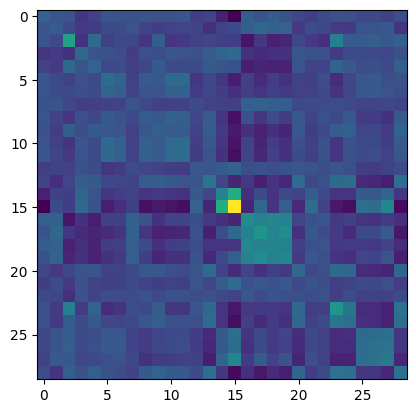

In [7]:
plt.imshow(GL_mdtb)

In [8]:
def HBP_u(train_data,cond_vec,part_vec):
    x_matrix = indicator(cond_vec)
    
    
    em_model = em.MixVMF(K=4, P=6918, X=x_matrix, part_vec=part_vec,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([train_data])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    

    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation

    return U_data

In [9]:
def evaluate_cos(D, ytrain,info, Vs, ytest, vtest,M_test):
    # Create a new column with combinations as tuples to make them hashable
    D['combination_tuple'] = D['combination'].apply(lambda x: tuple(x))
    
    # Get unique combinations
    unique_combinations = D['combination_tuple'].unique()
    
    # Initialize a dictionary to store cos_HBP for each unique combination
    cos_HBP_dict = {}
    cos_ols_dict = {}

    ytest = pt.tensor(ytest,dtype=pt.float32)
    vtest = pt.tensor(vtest,dtype=pt.float32)
    
    # Loop over each unique combination
    for i, comb_tuple in enumerate(unique_combinations):
        print(f"Processing combination: {i}")
        
        # Get the task subset indices and corresponding data
        task_subset_indices = list(comb_tuple)
        V_subset = Vs[task_subset_indices, :]
        V_subset = V_subset - np.mean(V_subset, axis=0)
        y_subset = ytrain[:, task_subset_indices, :]

        U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        U_hat_ols = pt.tensor(U_hat_ols,dtype=pt.float32)
        cos_ols = ev.coserr(ytest,vtest,U_hat_ols).mean().cpu().numpy()
        cos_ols = cos_ols.item()

        # leverage repeats for HBP
        HBP_data,HBP_cond_vec,HBP_part_vec = ut.make_dataset(ytrain,info,task_subset_indices,n_repeats=2)
        U_hat_HBP = [HBP_u(HBP_data, HBP_cond_vec, HBP_part_vec)]        
        
        # Compute cos_HBP
        cos_HBP = calc_test_error(M=M_test, tdata=ytest, U_hats=U_hat_HBP, fit_emission='use_Uhats').mean()
        
        # Store the result in the dictionary
        cos_HBP_dict[comb_tuple] = cos_HBP
        cos_ols_dict[comb_tuple] = cos_ols
    
    # Map the computed cos_HBP values back to the DataFrame
    D['cos_HBP'] = D['combination_tuple'].map(cos_HBP_dict)
    D['cos_ols'] = D['combination_tuple'].map(cos_ols_dict)
    
    return D

In [10]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0


data_mdtb_s2_run,info_mdtb_2_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s2',type='CondAll')
data_mdtb_s2_run[np.isnan(data_mdtb_s2_run)] = 0



In [11]:
cond_vec_test = np.tile(np.arange(1, 32 + 1), 1)
part_vec_test = np.repeat(np.arange(1, 1 + 1), 32)
data_test = data_mdtb_s2_run


x_matrix = indicator(cond_vec_test)


em_model = em.MixVMF(K=4, P=6918, X=x_matrix, part_vec=part_vec_test,
                    subject_specific_kappa=False, parcel_specific_kappa=False, 
                    subjects_equal_weight=True)

M_2 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
M_2.initialize([data_test])

M_2, ll,_,U_individual = M_2.fit_em(iter=200, tol=0.01,
                                fit_arrangement=False,
                                fit_emission= True,
                                first_evidence=False)    


In [17]:
offsets = np.logspace(-10, 10, num=50)
D_mdtb = ut.build_combinations(GL_mdtb, strategy='random',offs = offsets,n_iter=5000,n_tasks=8,seed=56)
D_mdtb = evaluate_cos(D_mdtb, data_mdtb_s1_run,info_mdtb_1_run,VL_mdtb, data_mdtb_s2_run, VL_mdtb_2,M_2)


building0
Processing combination: 0
Subject:0:0.0194s
Subject:1:0.0189s
Subject:2:0.0173s
Subject:3:0.0175s
Subject:4:0.0162s
Subject:5:0.0162s
Subject:6:0.0180s
Subject:7:0.0200s
Subject:8:0.0154s
Subject:9:0.0156s
Subject:10:0.0155s
Subject:11:0.0200s
Subject:12:0.0153s
Subject:13:0.0151s
Subject:14:0.0154s
Subject:15:0.0156s
Subject:16:0.0183s
Subject:17:0.0197s
Subject:18:0.0157s
Subject:19:0.0150s
Subject:20:0.0166s
Subject:21:0.0184s
Subject:22:0.0147s
Subject:23:0.0191s
Processing combination: 1
Likelihood decreased - terminating on iteration 44
Subject:0:0.0192s
Subject:1:0.0146s
Subject:2:0.0150s
Subject:3:0.0149s
Subject:4:0.0188s
Subject:5:0.0196s
Subject:6:0.0149s
Subject:7:0.0156s
Subject:8:0.0166s
Subject:9:0.0177s
Subject:10:0.0153s
Subject:11:0.0191s
Subject:12:0.0146s
Subject:13:0.0178s
Subject:14:0.0144s
Subject:15:0.0160s
Subject:16:0.0165s
Subject:17:0.0169s
Subject:18:0.0152s
Subject:19:0.0186s
Subject:20:0.0150s
Subject:21:0.0167s
Subject:22:0.0182s
Subject:23:0.0

In [ ]:
# save the dataframe in the current directory
# D_mdtb.to_csv('D_mdtb_comp.csv.gz', index=False,compression='gzip')

# load the dataframe
# D_mdtb = pd.read_csv('D_mdtb.csv')

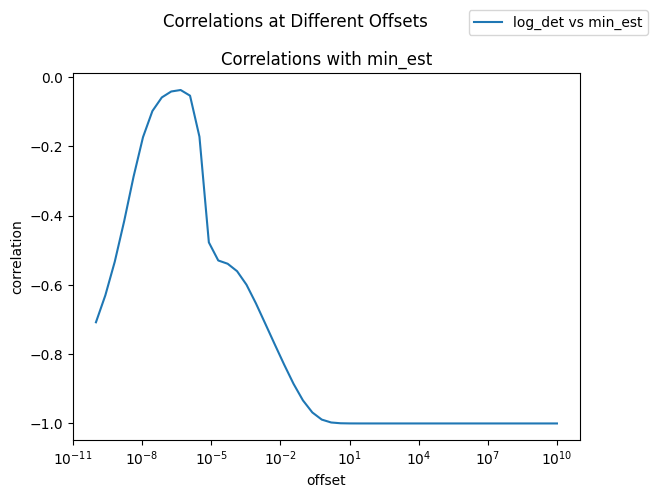

In [18]:
plot_correlations(D_mdtb, x_vars=['log_det'], y_vars=['min_est'])

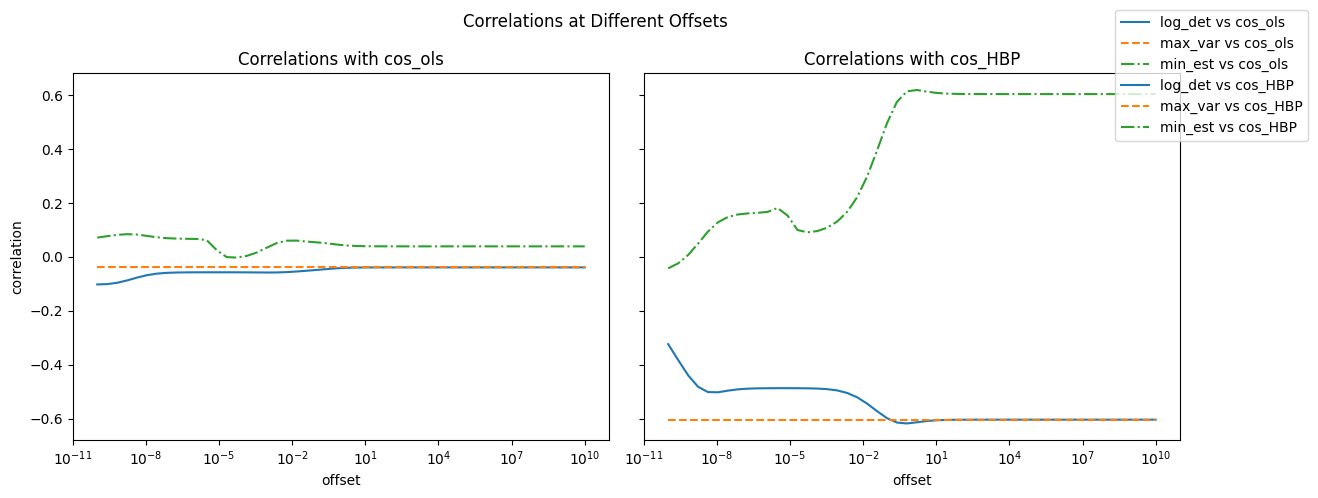

In [19]:
plot_correlations(D_mdtb, x_vars=['log_det','max_var','min_est'], y_vars=['cos_ols','cos_HBP'], show_p_values=False)